# 🌾 RICE VISION AI: PIPELINE CHÍNH ƯỚC LƯỢNG SỐ LƯỢNG & ĐÁNH GIÁ PHẨM CẤP (3D ELLIPSOID + REGRESSION BUNDLE)
**Đề tài Nghiên cứu Khoa học**: Hệ thống thị giác máy tính và học sâu phục vụ ước lượng số lượng và đánh giá phẩm cấp hạt giống lúa.

---

### 🌟 Tính năng nổi bật của Pipeline:
1. **Chuyển đổi linh hoạt 2 chế độ (`USE_CROPPED_CONTAINER`)**:
   - `False`: Quét SAHI trên **Ảnh gốc toàn cảnh** (mặc định theo yêu cầu).
   - `True`: Quét SAHI trên **Ảnh đã crop & cô lập miệng ly** (để loại bỏ nhiễu nền ngoài khi cần).
2. **Tầng 1 (Vật chứa)**: Nhận diện **Mép Trong & Mép Ngoài** miệng ly bằng thuật toán đồng tâm hình học chuẩn xác, tính tỷ lệ quy đổi $px/mm$ và thể tích khối lúa $V_{\text{bulk}}$ ($mm^3$).
3. **Tầng 2 (Bóc tách hạt SAHI - GPU)**: Quét trượt lát cắt nhỏ (**SAHI + YOLO-seg trên GPU cuda:0**) bóc tách từng hạt lúa thành ảnh RGBA trong suốt.
4. **Tầng 3 (Khử nhiễu 2 bước Grain Cleaner)**: Đưa từng hạt qua **2 lần làm sạch chuyên sâu (Step 1 + Step 2)** tương thích 100% với dữ liệu huấn luyện của mô hình CNN mới.
5. **Tầng 4 (Sàng lọc Hạt Nguyên bằng CNN v3_step2 - Batch GPU)**: Phân loại mẻ hạt lúa bằng **DenseNet121 CNN (`best_v3_step2.keras`) trên GPU** để **chọn lọc riêng các hạt NGUYÊN đạt chuẩn**.
6. **Tầng 5 (Mô hình hóa 3D cho Hạt Nguyên & IQR)**: Tính kích thước 2D/3D ($2a$: Chiều dài, $2b$: Chiều rộng, $2c$: Chiều dày) và thể tích 3D Ellipsoid $V_{\text{grain}} = \frac{4}{3}\pi abc$ ($mm^3$) **chuyên biệt cho tập hạt nguyên**, lọc bỏ dị thường bằng **IQR**.
7. **Tầng 6 (Trực quan hóa 3D & Ước lượng vật lý cổ điển)**: Vẽ mô hình không gian 3D Ellipsoid, trực quan hóa 2 trục chính trên từng hạt, vẽ phân bố kích thước 3D và ước lượng theo công thức vật lý: $N_{\text{est}} = \frac{V_{\text{bulk}} \times \phi}{\bar{V}_{\text{whole\_grain}}}$.
8. **Tầng 7 (Dự đoán hồi quy AI - 31 features)**: Trích xuất vector 31 đặc trưng và dự đoán bằng bundle model/scaler được chọn; kết quả phụ thuộc mô hình và dữ liệu kiểm chứng.


In [ ]:
# Bước 1: Kết nối Google Drive & Cài đặt thư viện
from google.colab import drive
import os

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

!pip install ultralytics sahi tensorflow matplotlib seaborn opencv-python numpy pandas joblib scikit-learn==1.6.1


In [ ]:
# Bước 2: Import Modules, Kiểm Tra GPU & Nạp Trọng Số Model (YOLO-seg & CNN v3_step2)
import os
import sys
import math
import shutil
import importlib
import torch
import tensorflow as tf
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D

# CẤU HÌNH ĐƯỜNG DẪN DỰ ÁN TRÊN GOOGLE DRIVE / LOCAL
BASE_PATH = "/content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES"

code_dir = os.path.join(BASE_PATH, "CODE")
if code_dir not in sys.path:
    sys.path.insert(0, code_dir)

# Import và tự động reload các module nghiệp vụ cốt lõi
import modules.container_detector
import modules.grain_segmenter
import modules.grain_crop_cleaner
import modules.grain_classifier
import modules.ellipsoid_geometry
import modules.uniformity_evaluator

for mod in [
    modules.container_detector,
    modules.grain_segmenter,
    modules.grain_crop_cleaner,
    modules.grain_classifier,
    modules.ellipsoid_geometry,
    modules.uniformity_evaluator
]:
    importlib.reload(mod)

from modules.container_detector import detect_container_and_scale, draw_container_overlay
from modules.grain_segmenter import segment_grains_sahi
from modules.grain_crop_cleaner import clean_single_grain_crop
from modules.grain_classifier import GrainClassifier
from modules.ellipsoid_geometry import compute_single_grain_metrics, draw_grain_ellipse_overlay
from modules.uniformity_evaluator import evaluate_batch_uniformity

# ─────────────────────────────────────────────────────────────────────────────
# KIỂM TRA PHẦN CỨNG TĂNG TỐC GPU (PYTORCH & TENSORFLOW)
# ─────────────────────────────────────────────────────────────────────────────
gpu_available = torch.cuda.is_available()
device_str = "cuda:0" if gpu_available else "cpu"
gpu_name = torch.cuda.get_device_name(0) if gpu_available else "CPU (Không có GPU)"

print("=" * 75)
print(f"⚡ Trạng thái GPU (PyTorch)   : {'✅ ' + gpu_name + ' (cuda:0)' if gpu_available else '❌ CPU (Vào Runtime -> Change runtime type -> T4 GPU)'}")
tf_gpus = tf.config.list_physical_devices('GPU')
print(f"⚡ Trạng thái GPU (TensorFlow): {'✅ ' + tf_gpus[0].name if tf_gpus else '❌ CPU'}")
print("=" * 75)

# ĐƯỜNG DẪN TRỌNG SỐ MÔ HÌNH
YOLO_MODEL_PATH = os.path.join(BASE_PATH, "RESULTS/all-new-data-v1.yolov8_yolov8s-seg_trained/weights/best.pt")
if not os.path.exists(YOLO_MODEL_PATH):
    YOLO_MODEL_PATH = os.path.join(BASE_PATH, "RESULTS/35_special_images_segmentation.v1i.yolov8_v1_trained/weights/best.pt")

CNN_MODEL_PATH = os.path.join(BASE_PATH, "RESULTS/CNN_DenseNet121_Trained/best_v3_step2.keras")

print(f"🔹 YOLO Model : {YOLO_MODEL_PATH}")
print(f"🔹 CNN Model  : {CNN_MODEL_PATH}")

# Nạp mô hình AI trên GPU
from sahi import AutoDetectionModel
print(f"⏳ Đang nạp mô hình SAHI YOLO-seg trên [{device_str}]...")
sahi_yolo_model = AutoDetectionModel.from_pretrained(
    model_type="yolov8",
    model_path=YOLO_MODEL_PATH,
    confidence_threshold=0.5,
    device=device_str
)

print("⏳ Đang nạp mô hình DenseNet121 (best_v3_step2.keras)...")
cnn_classifier = GrainClassifier(
    model_path=CNN_MODEL_PATH,
    class_names=["hat_khuyet_tat", "hat_nguyen"],
    target_size=(224, 224)
)
print("✅ Nạp toàn bộ mô hình AI thành công!")


⚡ Trạng thái GPU (PyTorch)   : ✅ Tesla T4 (cuda:0)
⚡ Trạng thái GPU (TensorFlow): ✅ /physical_device:GPU:0
🔹 YOLO Model : /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/all-new-data-v1.yolov8_yolov8s-seg_trained/weights/best.pt
🔹 CNN Model  : /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/CNN_DenseNet121_Trained/best_v3_step2.keras
⏳ Đang nạp mô hình SAHI YOLO-seg trên [cuda:0]...
⏳ Đang nạp mô hình DenseNet121 (best_v3_step2.keras)...
📦 Đang nạp mô hình CNN từ: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/CNN_DenseNet121_Trained/best_v3_step2.keras...
✅ Nạp mô hình CNN thành công!
✅ Nạp toàn bộ mô hình AI thành công!


In [ ]:
# Bước 3: THIẾT LẬP ĐƯỜNG DẪN ẢNH, CHẾ ĐỘ QUÉT VÀ THÔNG SỐ VẬT CHỨA
# ─────────────────────────────────────────────────────────────────────────────
# [HƯỚNG DẪN]:
# 1. IMAGE_PATH: Đường dẫn ảnh cần phân tích (tải lên /content/ hoặc trỏ vào Drive).
# 2. USE_CROPPED_CONTAINER:
#    - False (Mặc định): Chạy SAHI trên ẢNH GỐC TOÀN CẢNH.
#    - True            : Chạy SAHI trên ẢNH ĐÃ CROP MIỆNG LY (loại bỏ nền bàn bên ngoài).
# ─────────────────────────────────────────────────────────────────────────────

# 1. ĐƯỜNG DẪN ẢNH ĐẦU VÀO CẦN DỰ ĐOÁN
IMAGE_PATH = "/content/20260920_113312[1].jpg"

if not os.path.exists(IMAGE_PATH):
    fallback_path = os.path.join(BASE_PATH, "DATASET_BUILDER/1_Raw_Images/M001/M001B.jpg")
    if os.path.exists(fallback_path):
        IMAGE_PATH = fallback_path
        print(f"⚠️ Không thấy /content/test_image.jpg -> Dùng ảnh mẫu demo: {IMAGE_PATH}")
    else:
        print(f"⚠️ Vui lòng upload ảnh cần dự đoán lên: {IMAGE_PATH}")

# 2. CHẾ ĐỘ QUÉT SAHI (CÔNG TẮC CHUYỂN ĐỔI LINH HOẠT)
USE_CROPPED_CONTAINER = False   # False = Dùng Ảnh Gốc | True = Dùng Ảnh Crop Miệng Ly

# 3. THÔNG SỐ VẬT CHỨA (ĐO THỰC TẾ)
INNER_DIAM_MM         = 17.8    # Đường kính MÉP TRONG miệng ly (mm)
CONTAINER_HEIGHT_MM   = 33.8    # Chiều cao toàn bộ thân ly (mm)
EMPTY_HEIGHT_MM       = 3.8    # Khoảng trống từ miệng ly đến mặt lúa (mm)
INPUT_WEIGHT_G        = 3.71   # Cân nặng mẫu (g); nhập một lần tại đây
PACKING_FRACTION      = 0.82    # Hệ số chèn lấp khối lúa (~0.80 - 0.85)
if not (0.80 <= PACKING_FRACTION <= 0.85):
    raise ValueError(f"PACKING_FRACTION={PACKING_FRACTION} không hợp lệ! Phải nằm trong khoảng 0.80-0.85")
CONF_THRESHOLD_NGUYEN = 0.7    # Ngưỡng xác suất để công nhận là Hạt Nguyên (0.50 - 0.70)

# 4. BỘ THAM SỐ 2 LẦN CLEAN (KHỬ NHIỄU DÍNH & CÔ LẬP HẠT)
CLEAN_PARAMS_STEP1 = {
    "open_ksize": 5,
    "min_neck_ratio": 0.20,
    "min_area": 35,
    "centrality_weight": 2.5,
    "fill_holes": False,
    "sever_bridges": True,
}

CLEAN_PARAMS_STEP2 = {
    "open_ksize": 3,
    "min_neck_ratio": 0.15,
    "min_area": 25,
    "centrality_weight": 2.2,
    "fill_holes": True,
    "sever_bridges": True,
}

# 5. CẤU HÌNH THƯ MỤC XUẤT KẾT QUẢ TẠI /content/
OUTPUT_DIR = "/content/pipeline_inference_results"
OUTPUT_RAW_CROPS_DIR     = os.path.join(OUTPUT_DIR, "1_raw_crops")
OUTPUT_CLEANED_CROPS_DIR = os.path.join(OUTPUT_DIR, "2_cleaned_crops")
OUTPUT_NGUYEN_DIR        = os.path.join(OUTPUT_DIR, "classified/hat_nguyen")
OUTPUT_KHUYET_DIR        = os.path.join(OUTPUT_DIR, "classified/hat_khuyet_tat")
OUTPUT_REPORT_DIR        = os.path.join(OUTPUT_DIR, "reports")

for d in [OUTPUT_DIR, OUTPUT_RAW_CROPS_DIR, OUTPUT_CLEANED_CROPS_DIR, OUTPUT_NGUYEN_DIR, OUTPUT_KHUYET_DIR, OUTPUT_REPORT_DIR]:
    os.makedirs(d, exist_ok=True)

print("=" * 70)
print(f"🖼️  Ảnh phân tích      : {IMAGE_PATH}")
print(f"🔄 Chế độ SAHI Target  : {'ẢNH CROP MIỆNG LY' if USE_CROPPED_CONTAINER else 'ẢNH GỐC TOÀN CẢNH'}")
print(f"📏 Kích thước ly       : ⌀ trong={INNER_DIAM_MM}mm | Cao={CONTAINER_HEIGHT_MM}mm | Hụt={EMPTY_HEIGHT_MM}mm")
print(f"⚖️  Khối lượng mẫu      : {INPUT_WEIGHT_G} g | Hệ số vật lý: {PACKING_FRACTION}")
print(f"🧹 Cleaner Config      : Step 1 (k=5, area=35) -> Step 2 (k=3, area=25, fill=True)")
print(f"💾 Thư mục kết quả     : {OUTPUT_DIR}")
print("=" * 70)


  TẦNG 1: QUY ĐỔI KÍCH THƯỚC VẬT CHỨA (ĐỒNG TÂM HÌNH HỌC CHUẨN XÁC)
  • Loại nhận diện                 : geometric_concentric_rim
  • Đường kính MÉP TRONG phát hiện : 1628 px (Mép ngoài: 1902 px)
  • Tỷ lệ quy đổi pixel           : 91.44 px/mm
  • Chiều cao khối lúa thực tế    : 30.0 mm
  • Thể tích khối lúa (V_bulk)    : 7,465.37 mm³
  • Tọa độ Crop Bounding Box       : Offset=(1954, 2892) | Size=2206x2206 px


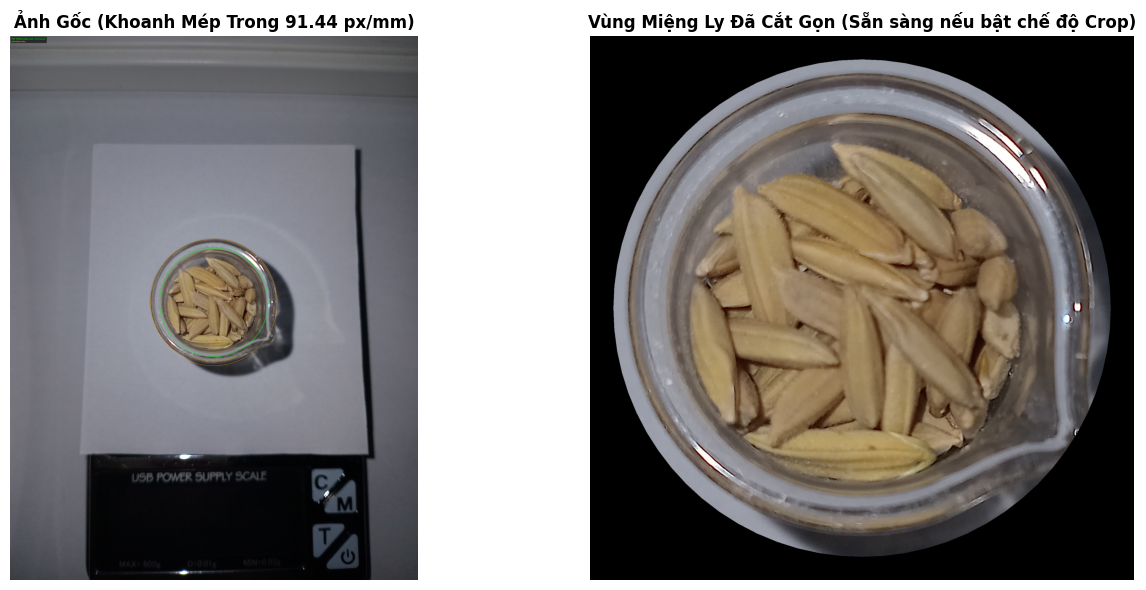

💾 Đã lưu ảnh cô lập miệng ly vào: /content/pipeline_inference_results/1_cropped_container.jpg


In [ ]:
# Bước 4: TẦNG 1 — Nhận diện Miệng Ly, Tính Thể tích Khối Lúa & Tạo Ảnh Crop
container_info = detect_container_and_scale(
    image_input=IMAGE_PATH,
    inner_diam_mm=INNER_DIAM_MM,
    container_height_mm=CONTAINER_HEIGHT_MM,
    empty_height_mm=EMPTY_HEIGHT_MM,
    detect_mode="inner"
)

pixels_per_mm = container_info["pixels_per_mm"]
bulk_volume_mm3 = container_info["bulk_rice_volume_mm3"]
crop_offset_x, crop_offset_y = container_info["crop_offset"]
cropped_container_bgr = container_info["cropped_bgr"]

# Lưu ảnh đã crop cô lập miệng ly ra đĩa
CROPPED_CONTAINER_PATH = os.path.join(OUTPUT_DIR, "1_cropped_container.jpg")
cv2.imwrite(CROPPED_CONTAINER_PATH, cropped_container_bgr)

# Lưu ảnh overlay vẽ khoanh mép trong / mép ngoài
vis_container = container_info["overlay_bgr"]
out_container_img = os.path.join(OUTPUT_DIR, "1_container_detection.jpg")
cv2.imwrite(out_container_img, vis_container)

print("=" * 70)
print("  TẦNG 1: QUY ĐỔI KÍCH THƯỚC VẬT CHỨA (ĐỒNG TÂM HÌNH HỌC CHUẨN XÁC)")
print("=" * 70)
print(f"  • Loại nhận diện                 : {container_info['detect_type']}")
print(f"  • Đường kính MÉP TRONG phát hiện : {container_info['inner_w_px']} px (Mép ngoài: {container_info['outer_w_px']} px)")
print(f"  • Tỷ lệ quy đổi pixel           : {pixels_per_mm:.2f} px/mm")
print(f"  • Chiều cao khối lúa thực tế    : {container_info['rice_height_mm']:.1f} mm")
print(f"  • Thể tích khối lúa (V_bulk)    : {bulk_volume_mm3:,.2f} mm³")
print(f"  • Tọa độ Crop Bounding Box       : Offset=({crop_offset_x}, {crop_offset_y}) | Size={cropped_container_bgr.shape[1]}x{cropped_container_bgr.shape[0]} px")
print("=" * 70)

# Hiển thị ảnh khoanh viền và ảnh đã cắt gọn miệng ly
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(cv2.cvtColor(vis_container, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Ảnh Gốc (Khoanh Mép Trong {pixels_per_mm:.2f} px/mm)", fontweight="bold")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(cropped_container_bgr, cv2.COLOR_BGR2RGB))
axes[1].set_title("Vùng Miệng Ly Đã Cắt Gọn (Sẵn sàng nếu bật chế độ Crop)", fontweight="bold")
axes[1].axis("off")
plt.tight_layout()
plt.show()
print(f"💾 Đã lưu ảnh cô lập miệng ly vào: {CROPPED_CONTAINER_PATH}")


In [ ]:
# Bước 5: TẦNG 2 — BÓC TÁCH HẠT BẰNG SAHI YOLO-SEG TRÊN GPU
if USE_CROPPED_CONTAINER:
    sahi_target_image = CROPPED_CONTAINER_PATH
    offset_x, offset_y = crop_offset_x, crop_offset_y
    print(f"⏳ Đang chạy SAHI YOLO-seg trên [ẢNH CROP MIỆNG LY]: {sahi_target_image}")
else:
    sahi_target_image = IMAGE_PATH
    offset_x, offset_y = 0, 0
    print(f"⏳ Đang chạy SAHI YOLO-seg trên [ẢNH GỐC TOÀN CẢNH]: {sahi_target_image}")

raw_grains = segment_grains_sahi(
    detection_model=sahi_yolo_model,
    image_path=sahi_target_image,
    output_crop_dir=OUTPUT_RAW_CROPS_DIR,
    conf_threshold=0.50,
    slice_size=640,
    overlap_ratio=0.25
)

# Cập nhật Bounding Box (local_bbox và global_bbox để vẽ ảnh toàn cảnh chuẩn xác)
for g in raw_grains:
    lx1, ly1, lx2, ly2 = g['bbox']
    g['local_bbox']  = [lx1, ly1, lx2, ly2]
    g['global_bbox'] = [lx1 + offset_x, ly1 + offset_y, lx2 + offset_x, ly2 + offset_y]

print(f"✅ Bóc tách hoàn tất: Phát hiện {len(raw_grains)} hạt lúa.")
print(f"📁 Đã lưu {len(raw_grains)} ảnh hạt thô vào: {OUTPUT_RAW_CROPS_DIR}")


⏳ Đang chạy SAHI YOLO-seg trên [ẢNH GỐC TOÀN CẢNH]: /content/20260920_113312[1].jpg
Performing prediction on 221 slices.
✅ Bóc tách hoàn tất: Phát hiện 71 hạt lúa.
📁 Đã lưu 71 ảnh hạt thô vào: /content/pipeline_inference_results/1_raw_crops


In [ ]:
# Bước 6: TẦNG 3 — ÁP DỤNG 2 LẦN CLEAN (STEP 1 + STEP 2) KHỬ NHIỄU DÍNH & BẺ EO
print(f"🧹 Đang thực hiện 2 lần Clean chuyên sâu cho {len(raw_grains)} hạt lúa...")

# Xóa file cũ trong thư mục cleaned
for f in os.listdir(OUTPUT_CLEANED_CROPS_DIR):
    fp = os.path.join(OUTPUT_CLEANED_CROPS_DIR, f)
    if os.path.isfile(fp): os.remove(fp)

cleaned_grains = []
discarded_count = 0

for idx, g in enumerate(raw_grains):
    raw_crop_rgba = g["crop_rgba"]
    grain_idx = g.get("grain_id", g.get("index", idx))

    # ── LẦN 1: Clean Step 1 (Open KSize = 5, Min Neck = 0.20, Min Area = 35) ──
    crop_step1 = clean_single_grain_crop(
        raw_crop_rgba,
        open_ksize=CLEAN_PARAMS_STEP1["open_ksize"],
        min_neck_ratio=CLEAN_PARAMS_STEP1["min_neck_ratio"],
        min_area=CLEAN_PARAMS_STEP1["min_area"],
        centrality_weight=CLEAN_PARAMS_STEP1["centrality_weight"],
        fill_holes=CLEAN_PARAMS_STEP1["fill_holes"],
        sever_bridges=CLEAN_PARAMS_STEP1["sever_bridges"],
    )

    # ── LẦN 2: Clean Step 2 (Open KSize = 3, Min Neck = 0.15, Min Area = 25, Fill = True) ──
    crop_step2 = clean_single_grain_crop(
        crop_step1,
        open_ksize=CLEAN_PARAMS_STEP2["open_ksize"],
        min_neck_ratio=CLEAN_PARAMS_STEP2["min_neck_ratio"],
        min_area=CLEAN_PARAMS_STEP2["min_area"],
        centrality_weight=CLEAN_PARAMS_STEP2["centrality_weight"],
        fill_holes=CLEAN_PARAMS_STEP2["fill_holes"],
        sever_bridges=CLEAN_PARAMS_STEP2["sever_bridges"],
    )

    # Kiểm tra mask sau 2 lần clean (nếu diện tích quá nhỏ hoặc rỗng -> loại bỏ nhiễu)
    alpha = crop_step2[:, :, 3] if len(crop_step2.shape) == 3 and crop_step2.shape[2] == 4 else None
    if alpha is not None and cv2.countNonZero(alpha) >= 20:
        g_clean = dict(g)
        g_clean["crop_rgba"] = crop_step2
        clean_bgr = crop_step2[:, :, :3].copy()
        clean_bgr[crop_step2[:, :, 3] == 0] = [0, 0, 0]
        g_clean["crop_bgr"] = clean_bgr

        # Lưu ảnh hạt đã clean sạch
        clean_save_path = os.path.join(OUTPUT_CLEANED_CROPS_DIR, f"grain_cleaned_{grain_idx:04d}.png")
        cv2.imwrite(clean_save_path, crop_step2)
        g_clean["saved_path"] = clean_save_path
        cleaned_grains.append(g_clean)
    else:
        discarded_count += 1

print("=" * 70)
print("✨ KẾT QUẢ KHỬ NHIỄU 2 LẦN (STEP 1 + STEP 2)")
print("=" * 70)
print(f"🔹 Tổng hạt thô ban đầu       : {len(raw_grains)} hạt")
print(f"🔹 Hạt lúa sạch giữ lại (✅)   : {len(cleaned_grains)} hạt")
print(f"🔹 Nhiễu vụn đã loại bỏ (🗑️)   : {discarded_count} mảnh")
print(f"📁 Đã lưu {len(cleaned_grains)} hạt sạch vào : {OUTPUT_CLEANED_CROPS_DIR}")
print("=" * 70)


🧹 Đang thực hiện 2 lần Clean chuyên sâu cho 71 hạt lúa...
✨ KẾT QUẢ KHỬ NHIỄU 2 LẦN (STEP 1 + STEP 2)
🔹 Tổng hạt thô ban đầu       : 71 hạt
🔹 Hạt lúa sạch giữ lại (✅)   : 71 hạt
🔹 Nhiễu vụn đã loại bỏ (🗑️)   : 0 mảnh
📁 Đã lưu 71 hạt sạch vào : /content/pipeline_inference_results/2_cleaned_crops


⏳ Đang phân loại 71 hạt lúa sạch bằng DenseNet121 CNN (Tăng tốc Batch GPU)...
📊 TẦNG 4: KẾT QUẢ SÀNG LỌC HẠT NGUYÊN (CHUẨN BỊ CHO BƯỚC ĐO 3D)
🔹 Tổng hạt lúa sạch trên mặt ly           : 71 hạt
🔹 Hạt NGUYÊN đạt chuẩn (ĐƯỢC CHỌN ĐO 3D)  : 9 hạt (12.7%)
🔹 Hạt khuyết tật / lép (Loại khỏi đo 3D)   : 62 hạt (87.3%)
📁 Đã lưu 9 hạt nguyên vào  : /content/pipeline_inference_results/classified/hat_nguyen
📁 Đã lưu 62 hạt khuyết tật vào: /content/pipeline_inference_results/classified/hat_khuyet_tat


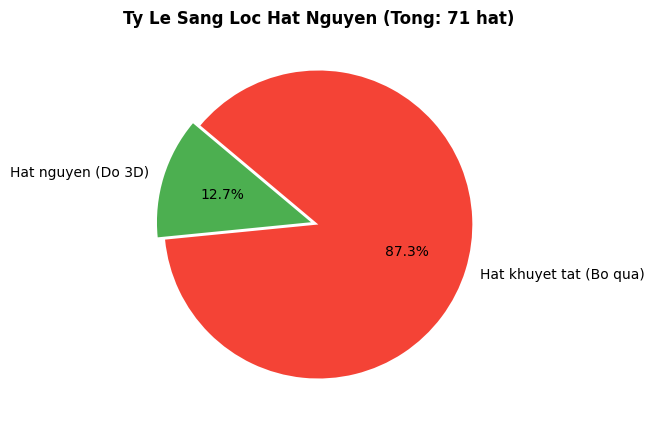

💾 Đã lưu biểu đồ phẩm cấp vào: /content/pipeline_inference_results/2_classification_pie_chart.png


In [ ]:
# Bước 7: TẦNG 4 — SÀNG LỌC HẠT NGUYÊN BẰNG DENSENET121 BATCH GPU (MODEL V3_STEP2)
print(f"⏳ Đang phân loại {len(cleaned_grains)} hạt lúa sạch bằng DenseNet121 CNN (Tăng tốc Batch GPU)...")

# Xóa sạch file cũ trong thư mục phân loại
for folder in [OUTPUT_NGUYEN_DIR, OUTPUT_KHUYET_DIR]:
    for f in os.listdir(folder):
        fp = os.path.join(folder, f)
        if os.path.isfile(fp): os.remove(fp)

whole_grains, defective_grains = cnn_classifier.filter_grains(
    cleaned_grains, target_label="hat_nguyen", min_conf=CONF_THRESHOLD_NGUYEN
)

# Lưu ảnh từng hạt vào thư mục phân loại tương ứng
for idx, g in enumerate(whole_grains):
    if "crop_rgba" in g and g["crop_rgba"] is not None:
        grain_idx = g.get("grain_id", g.get("index", idx))
        conf = g.get("confidence", 1.0)
        fname = f"grain_{grain_idx:04d}_conf{conf:.2f}.png"
        cv2.imwrite(os.path.join(OUTPUT_NGUYEN_DIR, fname), g["crop_rgba"])

for idx, g in enumerate(defective_grains):
    if "crop_rgba" in g and g["crop_rgba"] is not None:
        grain_idx = g.get("grain_id", g.get("index", idx))
        conf = g.get("confidence", 1.0)
        fname = f"grain_{grain_idx:04d}_conf{conf:.2f}.png"
        cv2.imwrite(os.path.join(OUTPUT_KHUYET_DIR, fname), g["crop_rgba"])

all_classified_grains = whole_grains + defective_grains
whole_ratio = (len(whole_grains) / len(cleaned_grains) * 100) if cleaned_grains else 0.0

print("=" * 70)
print("📊 TẦNG 4: KẾT QUẢ SÀNG LỌC HẠT NGUYÊN (CHUẨN BỊ CHO BƯỚC ĐO 3D)")
print("=" * 70)
print(f"🔹 Tổng hạt lúa sạch trên mặt ly           : {len(cleaned_grains)} hạt")
print(f"🔹 Hạt NGUYÊN đạt chuẩn (ĐƯỢC CHỌN ĐO 3D)  : {len(whole_grains)} hạt ({whole_ratio:.1f}%)")
print(f"🔹 Hạt khuyết tật / lép (Loại khỏi đo 3D)   : {len(defective_grains)} hạt ({100 - whole_ratio:.1f}%)")
print(f"📁 Đã lưu {len(whole_grains)} hạt nguyên vào  : {OUTPUT_NGUYEN_DIR}")
print(f"📁 Đã lưu {len(defective_grains)} hạt khuyết tật vào: {OUTPUT_KHUYET_DIR}")
print("=" * 70)

# Vẽ và lưu biểu đồ tròn
if cleaned_grains:
    plt.figure(figsize=(5, 5))
    plt.pie(
        [max(1, len(whole_grains)), max(1, len(defective_grains))],
        labels=['Hat nguyen (Do 3D)', 'Hat khuyet tat (Bo qua)'],
        autopct='%.1f%%',
        colors=['#4CAF50', '#F44336'],
        startangle=140,
        explode=(0.05, 0)
    )
    plt.title(f"Ty Le Sang Loc Hat Nguyen (Tong: {len(cleaned_grains)} hat)", fontweight='bold')
    pie_chart_path = os.path.join(OUTPUT_DIR, "2_classification_pie_chart.png")
    plt.savefig(pie_chart_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"💾 Đã lưu biểu đồ phẩm cấp vào: {pie_chart_path}")


🎯 Đang tính kích thước 2D và Thể tích 3D Ellipsoid cho 9 HẠT NGUYÊN...
  TẦNG 5: KẾT QUẢ ĐO KÍCH THƯỚC 3D & ĐỘ ĐỒNG ĐỀU (CHỈ DÀNH CHO HẠT NGUYÊN)
  • Số hạt nguyên đưa vào đo 3D     : 9 hạt
  • Chiều dài hạt (2a - Dài)        : Mean=5.09 mm | Min=2.91 mm | Max=6.60 mm | Std=1.19
  • Chiều rộng hạt (2b - Rộng)      : Mean=1.70 mm | Min=1.21 mm | Max=2.05 mm | Std=0.25
  • Chiều dày hạt (2c - Dày)        : Mean=4.32 mm (Hệ số k=1.0 cho hạt nguyên)
  • Diện tích 2D (Area)             : Mean=6.28 mm²
  • Thể tích 3D Ellipsoid tb (V_tb) : 20.85 mm³ (sau khi loại bỏ dị thường bằng IQR)
  • Độ đồng đều lô hạt nguyên       : 100.0% -> ✅ ĐẠT CHUẨN ĐỒNG ĐỀU (>= 80%)
💾 Đã lưu dữ liệu 3D hạt nguyên vào: /content/pipeline_inference_results/reports/whole_grains_3d_measurements.csv

📋 [BẢNG KÍCH THƯỚC 3D MẪU CỦA 10 HẠT NGUYÊN ĐẦU TIÊN]:


,grain_id,label,confidence,length_mm_2a,width_mm_2b,thickness_mm_2c,area_mm2,volume_3d_mm3
0,1,hat_nguyen,0.9864,6.60,1.80,5.61,8.79,34.92
1,5,hat_nguyen,0.8804,4.80,2.05,4.08,6.84,20.96
2,6,hat_nguyen,0.9600,5.81,1.75,4.94,7.54,26.26
3,9,hat_nguyen,0.9363,4.19,1.99,3.56,6.12,15.59
4,11,hat_nguyen,0.7581,4.54,1.83,3.86,5.67,16.83
5,12,hat_nguyen,0.9650,6.12,1.68,5.20,7.89,28.00
6,14,hat_nguyen,0.8919,6.59,1.51,5.60,6.99,29.21
7,33,hat_nguyen,0.7190,2.91,1.21,2.47,2.37,4.54
8,67,hat_nguyen,0.9960,4.21,1.44,3.58,4.33,11.35


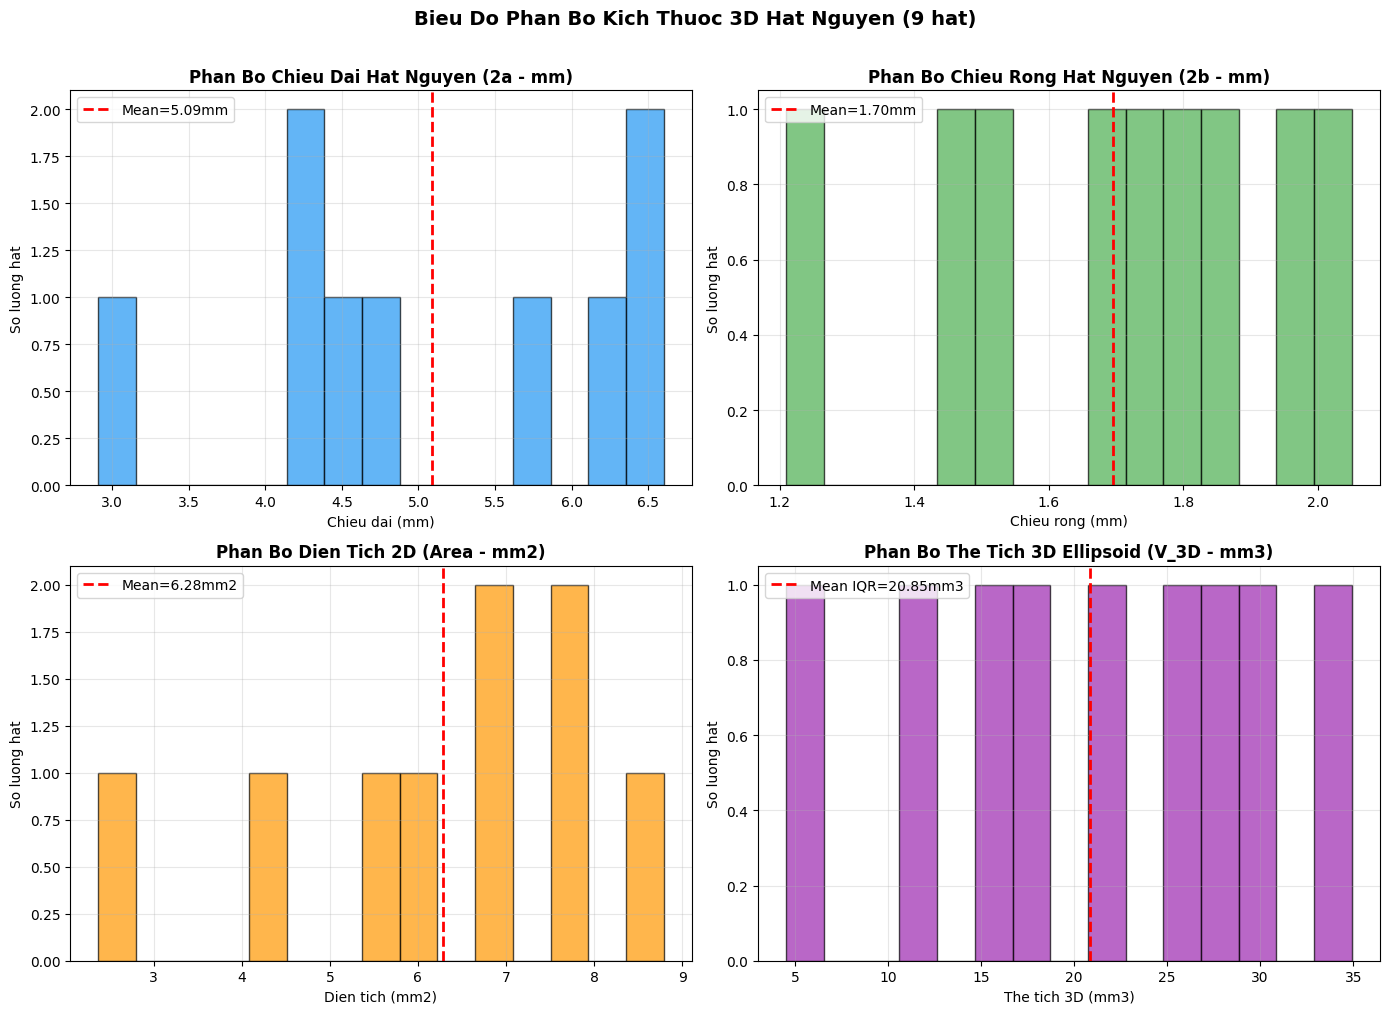

💾 Đã lưu biểu đồ phân bố kích thước 3D vào: /content/pipeline_inference_results/3_3d_dimensions_distribution.png


In [ ]:
# Bước 8: TẦNG 5 — MÔ HÌNH HÓA 3D ELLIPSOID, ĐO ĐẠC KÍCH THƯỚC & ĐÁNH GIÁ PHÂN BỐ
if len(whole_grains) > 0:
    grains_to_measure_3d = whole_grains
    print(f"🎯 Đang tính kích thước 2D và Thể tích 3D Ellipsoid cho {len(grains_to_measure_3d)} HẠT NGUYÊN...")
else:
    print("⚠️ CẢNH BÁO: Không phát hiện hạt nguyên nào, fallback đo tập hạt sạch để tránh dừng pipeline.")
    grains_to_measure_3d = cleaned_grains

whole_grain_metrics_list = []
whole_volumes_list = []
whole_records = []

for idx, g in enumerate(grains_to_measure_3d):
    try:
        # Tính hình học 3D Ellipsoid cho hạt nguyên (k_factor = 1.0)
        m = compute_single_grain_metrics(g["crop_rgba"], pixels_per_mm=pixels_per_mm, label="hat_nguyen")
        whole_grain_metrics_list.append(m)
        whole_volumes_list.append(m["volume_mm3"])
        grain_idx = g.get("grain_id", g.get("index", idx))
        whole_records.append({
            "grain_id": grain_idx,
            "label": "hat_nguyen",
            "confidence": round(g.get("confidence", 1.0), 4),
            "length_mm_2a": round(m["length_mm"], 2),
            "width_mm_2b": round(m["width_mm"], 2),
            "thickness_mm_2c": round(m["thickness_mm"], 2),
            "area_mm2": round(m["area_mm2"], 2),
            "volume_3d_mm3": round(m["volume_mm3"], 2)
        })
    except Exception:
        continue

# Lọc ngoại lai IQR chuyên biệt trên tập HẠT NGUYÊN
uniformity_res = evaluate_batch_uniformity(whole_volumes_list, threshold_rate=0.80)
mean_whole_grain_vol = uniformity_res["mean_clean"]

# Ước lượng tổng số hạt lúa theo hệ số chèn lấp phi
if mean_whole_grain_vol > 0 and bulk_volume_mm3 > 0:
    estimated_seed_count = int(round((bulk_volume_mm3 * PACKING_FRACTION) / mean_whole_grain_vol))
else:
    estimated_seed_count = 0

# Tạo DataFrame và lưu file CSV
df_whole_grains = pd.DataFrame(whole_records)
csv_whole_path = os.path.join(OUTPUT_REPORT_DIR, "whole_grains_3d_measurements.csv")
df_whole_grains.to_csv(csv_whole_path, index=False, encoding="utf-8-sig")

print("=" * 75)
print("  TẦNG 5: KẾT QUẢ ĐO KÍCH THƯỚC 3D & ĐỘ ĐỒNG ĐỀU (CHỈ DÀNH CHO HẠT NGUYÊN)")
print("=" * 75)
lengths = [r["length_mm_2a"] for r in whole_records]
widths  = [r["width_mm_2b"] for r in whole_records]
thick   = [r["thickness_mm_2c"] for r in whole_records]
areas   = [r["area_mm2"] for r in whole_records]
vols    = [r["volume_3d_mm3"] for r in whole_records]

if lengths:
    print(f"  • Số hạt nguyên đưa vào đo 3D     : {len(whole_records)} hạt")
    print(f"  • Chiều dài hạt (2a - Dài)        : Mean={np.mean(lengths):.2f} mm | Min={np.min(lengths):.2f} mm | Max={np.max(lengths):.2f} mm | Std={np.std(lengths):.2f}")
    print(f"  • Chiều rộng hạt (2b - Rộng)      : Mean={np.mean(widths):.2f} mm | Min={np.min(widths):.2f} mm | Max={np.max(widths):.2f} mm | Std={np.std(widths):.2f}")
    print(f"  • Chiều dày hạt (2c - Dày)        : Mean={np.mean(thick):.2f} mm (Hệ số k=1.0 cho hạt nguyên)")
    print(f"  • Diện tích 2D (Area)             : Mean={np.mean(areas):.2f} mm²")
    print(f"  • Thể tích 3D Ellipsoid tb (V_tb) : {mean_whole_grain_vol:.2f} mm³ (sau khi loại bỏ dị thường bằng IQR)")
    print(f"  • Độ đồng đều lô hạt nguyên       : {uniformity_res['uniformity_rate_pct']}% -> {'✅ ĐẠT CHUẨN ĐỒNG ĐỀU (>= 80%)' if uniformity_res['is_uniform'] else '❌ CHƯA ĐẠT ĐỒNG ĐỀU'}")
print(f"💾 Đã lưu dữ liệu 3D hạt nguyên vào: {csv_whole_path}")
print("=" * 75)

# Hiển thị bảng dữ liệu 10 hạt nguyên đầu tiên
print("\n📋 [BẢNG KÍCH THƯỚC 3D MẪU CỦA 10 HẠT NGUYÊN ĐẦU TIÊN]:")
display(df_whole_grains.head(10))

# Vẽ 4 biểu đồ phân bố kích thước 3D của tập hạt nguyên
if len(lengths) >= 3:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Phân bố chiều dài 2a
    axes[0, 0].hist(lengths, bins=15, color='#2196F3', edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(np.mean(lengths), color='red', linestyle='--', linewidth=2, label=f'Mean={np.mean(lengths):.2f}mm')
    axes[0, 0].set_title("Phan Bo Chieu Dai Hat Nguyen (2a - mm)", fontweight='bold')
    axes[0, 0].set_xlabel("Chieu dai (mm)")
    axes[0, 0].set_ylabel("So luong hat")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Phân bố chiều rộng 2b
    axes[0, 1].hist(widths, bins=15, color='#4CAF50', edgecolor='black', alpha=0.7)
    axes[0, 1].axvline(np.mean(widths), color='red', linestyle='--', linewidth=2, label=f'Mean={np.mean(widths):.2f}mm')
    axes[0, 1].set_title("Phan Bo Chieu Rong Hat Nguyen (2b - mm)", fontweight='bold')
    axes[0, 1].set_xlabel("Chieu rong (mm)")
    axes[0, 1].set_ylabel("So luong hat")
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Phân bố diện tích 2D
    axes[1, 0].hist(areas, bins=15, color='#FF9800', edgecolor='black', alpha=0.7)
    axes[1, 0].axvline(np.mean(areas), color='red', linestyle='--', linewidth=2, label=f'Mean={np.mean(areas):.2f}mm2')
    axes[1, 0].set_title("Phan Bo Dien Tich 2D (Area - mm2)", fontweight='bold')
    axes[1, 0].set_xlabel("Dien tich (mm2)")
    axes[1, 0].set_ylabel("So luong hat")
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 4. Phân bố thể tích 3D Ellipsoid
    axes[1, 1].hist(vols, bins=15, color='#9C27B0', edgecolor='black', alpha=0.7)
    axes[1, 1].axvline(mean_whole_grain_vol, color='red', linestyle='--', linewidth=2, label=f'Mean IQR={mean_whole_grain_vol:.2f}mm3')
    axes[1, 1].set_title("Phan Bo The Tich 3D Ellipsoid (V_3D - mm3)", fontweight='bold')
    axes[1, 1].set_xlabel("The tich 3D (mm3)")
    axes[1, 1].set_ylabel("So luong hat")
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle(f"Bieu Do Phan Bo Kich Thuoc 3D Hat Nguyen ({len(whole_records)} hat)", fontweight='bold', y=1.01, fontsize=14)
    plt.tight_layout()
    dist_chart_path = os.path.join(OUTPUT_DIR, "3_3d_dimensions_distribution.png")
    plt.savefig(dist_chart_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"💾 Đã lưu biểu đồ phân bố kích thước 3D vào: {dist_chart_path}")


╔══════════════════════════════════════════════════════════════════════╗
║                    🏆 BẢNG KẾT QUẢ RICE VISION AI                     ║
╠══════════════════════════════════════════════════════════════════════╣
║  📸 Ảnh phân tích         : 20260920_113312[1].jpg                     ║
║  📏 Thể tích khối lúa (V) : 7,465.4    mm³                           ║
║  🌾 Số hạt bề mặt         : 71   hạt (Nguyên: 9, Khuyết: 62)         ║
║  🌟 Phẩm cấp hạt nguyên   : 12.7 %                                   ║
║  📐 Thể tích 1 hạt nguyên : 20.85  mm³ (Lọc IQR)               ║
║  📊 Độ đồng đều           : 100.0% (ĐẠT CHUẨN)                       ║
╠══════════════════════════════════════════════════════════════════════╣
║  🎯 DỰ ĐOÁN TỔNG SỐ HẠT   : 294    HẠT (Hệ số phi = 0.82)           ║
╚══════════════════════════════════════════════════════════════════════╝


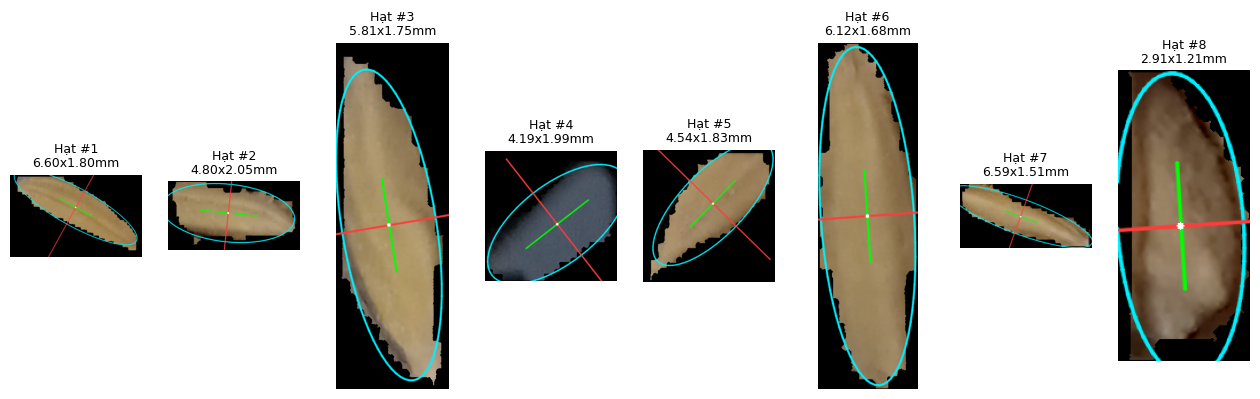

True

In [ ]:
print("╔" + "═" * 70 + "╗")
print("║" + "🏆 BẢNG KẾT QUẢ RICE VISION AI".center(70) + "║")
print("╠" + "═" * 70 + "╣")
print(f"║  📸 Ảnh phân tích         : {os.path.basename(IMAGE_PATH):<42} ║")
print(f"║  📏 Thể tích khối lúa (V) : {bulk_volume_mm3:<10,.1f} mm³                           ║")
print(f"║  🌾 Số hạt bề mặt         : {len(cleaned_grains):<4} hạt (Nguyên: {len(whole_grains)}, Khuyết: {len(defective_grains)})         ║")
print(f"║  🌟 Phẩm cấp hạt nguyên   : {whole_ratio:<5.1f}%                                   ║")
print(f"║  📐 Thể tích 1 hạt nguyên : {mean_whole_grain_vol:<6.2f} mm³ (Lọc IQR)               ║")
print(f"║  📊 Độ đồng đều           : {uniformity_res['uniformity_rate_pct']:<5.1f}% ({'ĐẠT CHUẨN' if uniformity_res['is_uniform'] else 'CHƯA ĐẠT'})                       ║")
print("╠" + "═" * 70 + "╣")
print(f"║  🎯 DỰ ĐOÁN TỔNG SỐ HẠT   : {estimated_seed_count:<6} HẠT (Hệ số phi = {PACKING_FRACTION})           ║")
print("╚" + "═" * 70 + "╝")

summary_df = pd.DataFrame([{
    "image_name": os.path.basename(IMAGE_PATH),
    "bulk_volume_mm3": round(bulk_volume_mm3, 2),
    "whole_grains": len(whole_grains),
    "estimated_seed_count": estimated_seed_count
}])
summary_csv_path = os.path.join(OUTPUT_REPORT_DIR, "final_summary_report.csv")
summary_df.to_csv(summary_csv_path, index=False, encoding="utf-8-sig")

if whole_grain_metrics_list:
    num_show = min(8, len(whole_grain_metrics_list))
    plt.figure(figsize=(16, 4.5))
    for i in range(num_show):
        plt.subplot(1, num_show, i + 1)
        m = whole_grain_metrics_list[i]
        vis_g = draw_grain_ellipse_overlay(grains_to_measure_3d[i]["crop_rgba"], m)
        plt.imshow(vis_g)
        plt.title(f"Hạt #{i+1}\n{m['length_mm']:.2f}x{m['width_mm']:.2f}mm", fontsize=9)
        plt.axis('off')
    plt.show()

img_raw = cv2.imread(IMAGE_PATH)
img_vis = img_raw.copy() if img_raw is not None else container_info["overlay_bgr"].copy()
for grain in (all_classified_grains if 'all_classified_grains' in locals() else cleaned_grains):
    x1, y1, x2, y2 = map(int, grain.get('global_bbox', grain['bbox']))
    color = (0, 220, 0) if grain.get('predicted_label') == "hat_nguyen" else (0, 0, 230)
    cv2.rectangle(img_vis, (x1, y1), (x2, y2), color, 2)
cv2.imwrite(os.path.join(OUTPUT_DIR, "6_full_detection_result.jpg"), img_vis)

In [15]:
# ==============================================================================
# REGRESSION_CONFIG: CHỈ CHỌN BUNDLE; THÔNG SỐ MẪU ĐÃ NHẬP Ở BƯỚC 3
# ==============================================================================
import os

# Xóa state kết quả cũ nếu chạy lại
if 'regression_bundle' in locals(): del regression_bundle
if 'regression_features' in locals(): del regression_features
if 'regression_result' in locals(): del regression_result

# 1. ĐƯỜNG DẪN ĐẾN THƯ MỤC BUNDLE MÔ HÌNH
# Đổi thư mục này nếu muốn thử bundle hồi quy khác
REGRESSION_MODEL_DIR = "LINEAR_REGRESSION_MODEL/models/extra_trees"

# Dùng lại cân nặng, kích thước và hệ số vật lý ở Bước 3; không nhập lại.

# Xử lý đường dẫn
resolved_model_dir = REGRESSION_MODEL_DIR
if not os.path.isabs(resolved_model_dir):
    resolved_model_dir = os.path.abspath(os.path.join(BASE_PATH, resolved_model_dir))

print(f"📂 Thư mục bundle mô hình được chọn: {resolved_model_dir}")
print(f"⚖️  Dùng khối lượng mẫu ở Bước 3: {INPUT_WEIGHT_G} g")


📂 Thư mục bundle mô hình được chọn: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/LINEAR_REGRESSION_MODEL/models/extra_trees
⚖️  Dùng khối lượng mẫu ở Bước 3: 3.71 g


In [16]:
# ==============================================================================
# REGRESSION_BUNDLE_LOADER: NẠP VÀ KIỂM TRA TÍNH TOÀN VẸN CỦA BUNDLE
# ==============================================================================
import json
import joblib
from sklearn.utils.validation import check_is_fitted

def load_regression_bundle(model_dir):
    schema_path = os.path.join(model_dir, "feature_schema.json")
    model_path = os.path.join(model_dir, "model.joblib")
    scaler_path = os.path.join(model_dir, "scaler.joblib")
    config_path = os.path.join(model_dir, "config.json")
    metrics_path = os.path.join(model_dir, "metrics.json")

    if not os.path.exists(model_dir):
        raise FileNotFoundError(f"Không tìm thấy thư mục mô hình: {model_dir}")
    if not os.path.exists(schema_path):
        raise FileNotFoundError(f"Thiếu feature_schema.json trong {model_dir}")
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Thiếu model.joblib trong {model_dir}")

    with open(schema_path, "r", encoding="utf-8") as f:
        schema = json.load(f)

    if schema.get("schema_version") != "31v1":
        raise ValueError("Chỉ hỗ trợ schema_version '31v1'")

    ordered_features = schema.get("features", [])
    if len(ordered_features) != 31 or "Actual_Count" in ordered_features:
        raise ValueError("Schema phải chứa chính xác 31 features và không có Actual_Count.")

    EXPECTED_31_FEATURES = [
        "Bulk_Rice_Volume_mm3", "Rice_Height_mm", "Weight_g", "Empty_Height_mm",
        "Pixels_Per_mm", "Container_Detected_Diam_px", "Inner_Diameter_mm", "Container_Height_mm",
        "Whole_Grains_Count", "Uniformity_Rate_Pct", "Estimated_Total_Seeds_Hybrid",
        "Grain_Length_mm_Mean", "Grain_Length_mm_Min", "Grain_Length_mm_Max", "Grain_Length_mm_Std",
        "Grain_Width_mm_Mean", "Grain_Width_mm_Min", "Grain_Width_mm_Max", "Grain_Width_mm_Std",
        "Grain_Thickness_mm_Mean", "Grain_Thickness_mm_Min", "Grain_Thickness_mm_Max", "Grain_Thickness_mm_Std",
        "Grain_Area_mm2_Mean", "Grain_Area_mm2_Min", "Grain_Area_mm2_Max", "Grain_Area_mm2_Std",
        "Grain_Volume_mm3_Mean", "Grain_Volume_mm3_Min", "Grain_Volume_mm3_Max", "Grain_Volume_mm3_Std"
    ]
    if ordered_features != EXPECTED_31_FEATURES:
        raise ValueError("Danh sách và thứ tự feature không khớp với hợp đồng 31 features quy định.")

    config = {}
    if os.path.exists(config_path):
        with open(config_path, "r", encoding="utf-8") as f:
            config = json.load(f)

    # Bundle 31v1 hiện tại train từ CODE/modules/dataset_extractor.py với mặc định 0.62.
    # PACKING_FRACTION ở Bước 3 chỉ dùng cho ước lượng vật lý (0.80–0.85).
    # Bundle train lại với hệ số khác phải ghi hybrid_packing_fraction trong config.json.
    hybrid_fraction = float(config.get("hybrid_packing_fraction", 0.62))
    if not 0 < hybrid_fraction <= 1:
        raise ValueError(f"hybrid_packing_fraction của bundle không hợp lệ: {hybrid_fraction}")

    if config.get("preprocessing") != "none" and not os.path.exists(scaler_path):
        raise FileNotFoundError(f"Mô hình yêu cầu preprocessing nhưng thiếu scaler.joblib")
    if config.get("preprocessing") == "none" and os.path.exists(scaler_path):
        raise ValueError("Bundle mâu thuẫn: có file scaler.joblib nhưng config khai báo preprocessing='none'")

    try:
        import warnings
        with warnings.catch_warnings(record=True) as w:
            warnings.simplefilter("always")
            model = joblib.load(model_path)
            scaler = joblib.load(scaler_path) if os.path.exists(scaler_path) else None
            if w:
                for warn in w:
                    print(f"⚠️ Cảnh báo lúc load model/scaler: {warn.message}")
    except Exception as e:
        raise RuntimeError(f"Lỗi khi load model/scaler bằng joblib: {e}")

    if hasattr(model, "steps") and hasattr(model, "predict"):
        raise ValueError("model.joblib không được là Pipeline để tránh lặp preprocessing.")

    check_is_fitted(model)
    if hasattr(model, "feature_names_in_"):
        if len(model.feature_names_in_) != 31:
            raise ValueError(f"Mô hình yêu cầu {len(model.feature_names_in_)} features, nhưng schema cung cấp 31.")
        if list(model.feature_names_in_) != ordered_features:
            raise ValueError("Thứ tự features trong mô hình khác với schema.")

    metrics = {"unavailable": True}
    if os.path.exists(metrics_path):
        try:
            with open(metrics_path, "r", encoding="utf-8") as f:
                metrics = json.load(f)
        except json.JSONDecodeError:
            print(f"⚠️ Không thể đọc {metrics_path} (File bị hỏng)")

    return {
        "model": model,
        "scaler": scaler,
        "ordered_features": ordered_features,
        "schema_version": schema.get("schema_version"),
        "hybrid_packing_fraction": hybrid_fraction,
        "folder": model_dir,
        "config": config,
        "metrics": metrics
    }

print("🔄 Đang nạp bundle mô hình...")
regression_bundle = load_regression_bundle(resolved_model_dir)
print(f"✅ Nạp thành công mô hình: {regression_bundle['model'].__class__.__name__}")


🔄 Đang nạp bundle mô hình...
✅ Nạp thành công mô hình: ExtraTreesRegressor


In [17]:
# ==============================================================================
# REGRESSION_FEATURES: TRÍCH XUẤT ĐẶC TRƯNG TỪ QUY TRÌNH HÌNH HỌC
# ==============================================================================
import numpy as np
import pandas as pd
import math

def assemble_regression_features(bundle):
    if len(whole_grains) == 0:
        raise ValueError("Không tìm thấy hạt lúa nguyên nào (whole grains). Dừng suy luận regression.")

    if "INPUT_WEIGHT_G" not in globals() or INPUT_WEIGHT_G is None:
        raise ValueError("Thiếu dữ liệu cân nặng thật (INPUT_WEIGHT_G=None). Vui lòng cân chính xác mẫu.")
    actual_weight_g = float(INPUT_WEIGHT_G)
    if not np.isfinite(actual_weight_g) or actual_weight_g <= 0:
        raise ValueError(f"Dữ liệu cân nặng không hợp lệ: {actual_weight_g} g")

    # Đặc trưng train lấy measurements gốc, không lấy whole_records đã làm tròn cho CSV.
    if not whole_grain_metrics_list:
        raise ValueError("Không có measurements hạt hợp lệ để tạo 31 features.")
    lens_arr = np.array([float(m["length_mm"]) for m in whole_grain_metrics_list])
    wids_arr = np.array([float(m["width_mm"]) for m in whole_grain_metrics_list])
    thks_arr = np.array([float(m["thickness_mm"]) for m in whole_grain_metrics_list])
    area_arr = np.array([float(m["area_mm2"]) for m in whole_grain_metrics_list])
    vols_arr = np.array([float(m["volume_mm3"]) for m in whole_grain_metrics_list])
    for arr in (lens_arr, wids_arr, thks_arr, area_arr, vols_arr):
        if np.any(~np.isfinite(arr)) or np.any(arr <= 0):
            raise ValueError("Measurements chứa giá trị NaN, Inf hoặc <= 0.")

    if "rice_height_mm" not in container_info or "inner_w_px" not in container_info:
        raise ValueError("Thiếu thông số container_info (rice_height_mm hoặc inner_w_px).")

    def calc_stats(arr):
        return {
            "Mean": round(float(np.mean(arr)), 3),
            "Min": round(float(np.min(arr)), 3),
            "Max": round(float(np.max(arr)), 3),
            "Std": round(float(np.std(arr, ddof=0)), 3)
        }

    lens_st = calc_stats(lens_arr)
    wids_st = calc_stats(wids_arr)
    thks_st = calc_stats(thks_arr)
    area_st = calc_stats(area_arr)
    vols_st = calc_stats(vols_arr)

    from modules.uniformity_evaluator import evaluate_batch_uniformity
    batch_uniformity = evaluate_batch_uniformity(vols_arr.tolist())
    unif_rate = round(float(batch_uniformity.get("uniformity_rate_pct", 0.0)), 2)

    raw_bulk_volume = float(bulk_volume_mm3)
    mean_volume = float(np.mean(vols_arr))
    hybrid_estimate = int(round((raw_bulk_volume * bundle["hybrid_packing_fraction"]) / mean_volume))

    feat_dict = {
        "Bulk_Rice_Volume_mm3": round(raw_bulk_volume, 2),
        "Rice_Height_mm": round(float(container_info["rice_height_mm"]), 2),
        "Weight_g": actual_weight_g,
        "Empty_Height_mm": float(EMPTY_HEIGHT_MM),
        "Pixels_Per_mm": round(float(pixels_per_mm), 2),
        "Container_Detected_Diam_px": round(float(container_info["inner_w_px"]), 2),
        "Inner_Diameter_mm": float(INNER_DIAM_MM),
        "Container_Height_mm": float(CONTAINER_HEIGHT_MM),
        "Whole_Grains_Count": float(len(whole_records)),
        "Uniformity_Rate_Pct": unif_rate,
        "Estimated_Total_Seeds_Hybrid": float(hybrid_estimate),

        "Grain_Length_mm_Mean": lens_st["Mean"],
        "Grain_Length_mm_Min": lens_st["Min"],
        "Grain_Length_mm_Max": lens_st["Max"],
        "Grain_Length_mm_Std": lens_st["Std"],

        "Grain_Width_mm_Mean": wids_st["Mean"],
        "Grain_Width_mm_Min": wids_st["Min"],
        "Grain_Width_mm_Max": wids_st["Max"],
        "Grain_Width_mm_Std": wids_st["Std"],

        "Grain_Thickness_mm_Mean": thks_st["Mean"],
        "Grain_Thickness_mm_Min": thks_st["Min"],
        "Grain_Thickness_mm_Max": thks_st["Max"],
        "Grain_Thickness_mm_Std": thks_st["Std"],

        "Grain_Area_mm2_Mean": area_st["Mean"],
        "Grain_Area_mm2_Min": area_st["Min"],
        "Grain_Area_mm2_Max": area_st["Max"],
        "Grain_Area_mm2_Std": area_st["Std"],

        "Grain_Volume_mm3_Mean": vols_st["Mean"],
        "Grain_Volume_mm3_Min": vols_st["Min"],
        "Grain_Volume_mm3_Max": vols_st["Max"],
        "Grain_Volume_mm3_Std": vols_st["Std"]
    }

    for k, v in feat_dict.items():
        if not math.isfinite(v):
            raise ValueError(f"Feature {k} không phải là số hữu hạn: {v}")

    df = pd.DataFrame([feat_dict], columns=bundle["ordered_features"])
    return df

print("🔄 Đang trích xuất 31 đặc trưng...")
regression_features = assemble_regression_features(regression_bundle)
print(f"✅ Đặc trưng hợp lệ. Hybrid theo bundle (φ={regression_bundle['hybrid_packing_fraction']}): {regression_features['Estimated_Total_Seeds_Hybrid'].iloc[0]}")
print(f"ℹ️ Hệ số vật lý φ={PACKING_FRACTION} độc lập với feature hybrid đã train; đổi hệ số hybrid cần train lại bundle.")


🔄 Đang trích xuất 31 đặc trưng...
✅ Đặc trưng hợp lệ. Hybrid theo bundle (φ=0.62): 222.0
ℹ️ Hệ số vật lý φ=0.82 độc lập với feature hybrid đã train; đổi hệ số hybrid cần train lại bundle.


In [18]:
# ==============================================================================
# REGRESSION_PREDICT: THỰC THI SUY LUẬN SỐ LƯỢNG HẠT
# ==============================================================================

def predict_regression_bundle(bundle, features_df):
    model = bundle["model"]
    scaler = bundle["scaler"]

    if list(features_df.columns) != bundle["ordered_features"] or features_df.shape != (1, 31):
        raise ValueError("Vector dự đoán phải có đúng 31 features theo thứ tự của bundle.")
    if scaler is not None:
        scaler_input = features_df if hasattr(scaler, "feature_names_in_") else features_df.to_numpy()
        X_scaled = scaler.transform(scaler_input)
    else:
        X_scaled = features_df if hasattr(model, "feature_names_in_") else features_df.to_numpy()

    if not np.all(np.isfinite(X_scaled)):
        raise ValueError("Vector đặc trưng chứa NaN/Inf sau khi chuẩn hóa.")

    raw_pred = model.predict(X_scaled)
    if raw_pred.shape not in [(1,), (1, 1)]:
        raise ValueError(f"Mô hình trả về shape không hợp lệ: {raw_pred.shape}")

    raw_val = float(raw_pred.item())
    if not math.isfinite(raw_val):
        raise ValueError(f"Kết quả dự đoán không phải số hữu hạn: {raw_val}")

    return raw_val

print("🔄 Đang chạy suy luận...")
raw_predicted_count = predict_regression_bundle(regression_bundle, regression_features)
final_predicted_seeds = max(0, int(round(raw_predicted_count)))
regression_result = {
    "raw_count": raw_predicted_count,
    "final_count": final_predicted_seeds
}
print(f"✅ Dự đoán thành công: {final_predicted_seeds} hạt")


🔄 Đang chạy suy luận...
✅ Dự đoán thành công: 138 hạt


In [19]:
# ==============================================================================
# REGRESSION_REPORT: XUẤT KẾT QUẢ VÀ LƯU BÁO CÁO
# ==============================================================================
if 'regression_result' not in locals():
    raise RuntimeError("Chưa có kết quả. Vui lòng chạy các Cell phía trên tuần tự.")

metrics = regression_bundle["metrics"]
cv_mae = metrics.get("cv_summary", {}).get("cv_mae_mean", "N/A")
cv_r2 = metrics.get("cv_summary", {}).get("cv_r2_mean", "N/A")
test_mae = metrics.get("metrics_test", {}).get("mae", "N/A")

print("\n" + "╔" + "═" * 78 + "╗")
print("║" + " " * 22 + "🤖 KẾT QUẢ DỰ ĐOÁN HỒI QUY (AI)" + " " * 23 + "║")
print("╠" + "═" * 78 + "╣")
print(f"║  📸 Tệp ảnh phân tích      : {os.path.basename(IMAGE_PATH):<47} ║")
print(f"║  ⚖️  Khối lượng mẫu         : {INPUT_WEIGHT_G:<6.2f} gam {'':<46} ║")
print(f"║  🌾 Số hạt bề mặt ly       : {len(whole_grains):<3} hạt nguyên / {len(cleaned_grains):<3} hạt tổng{'':<18} ║")
print(f"║  📏 Thể tích khối lúa (V)  : {bulk_volume_mm3:<10,.1f} mm³{'':<33} ║")
print(f"║  📐 Thể tích 1 hạt nguyên  : {regression_features['Grain_Volume_mm3_Mean'].iloc[0]:<6.2f} mm³ {'':<36} ║")
print("╠" + "═" * 78 + "╣")
print(f"║  DỰ ĐOÁN VẬT LÝ (Cell 9): {estimated_seed_count:<5} HẠT (V_bulk * {PACKING_FRACTION} / V_grain_IQR){'':<6} ║")
print(f"║  DỰ ĐOÁN HỒI QUY (AI)   : \033[1;32m{regression_result['final_count']:<5}\033[0m HẠT {'':<39} ║")
print("╠" + "═" * 78 + "╣")
print(f"║  Thư mục Model: {REGRESSION_MODEL_DIR:<62} ║")
print(f"║  Mô hình      : {regression_bundle['model'].__class__.__name__:<20} | Scaler: {regression_bundle['scaler'].__class__.__name__ if regression_bundle['scaler'] else 'None':<24} ║")
print(f"║  Raw Predict  : {regression_result['raw_count']:<20.4f} | Training CV MAE: {cv_mae:<15} ║")
print("╚" + "═" * 78 + "╝\n")

print("⚠️ Chưa tính đóng góp từng feature (Bỏ biểu đồ contributions).")

# 6. CẬP NHẬT KẾT QUẢ DỰ ĐOÁN HỒI QUY VÀO FILE BÁO CÁO TỔNG HỢP
final_prediction_csv = os.path.join(OUTPUT_REPORT_DIR, "final_prediction_summary.csv")
prediction_summary_record = {
    "Image_Name": os.path.basename(IMAGE_PATH),
    "Bulk_Rice_Volume_mm3": round(float(bulk_volume_mm3), 2),
    "Mean_Grain_Volume_mm3": round(float(mean_whole_grain_vol), 2),
    "Whole_Grains_Count": len(whole_records),
    "Physical_Formula_Estimate": estimated_seed_count,
    "Linear_Regression_Predicted_Seeds": regression_result["final_count"],  # Tên cũ để tương thích CSV đã dùng
    "Regression_Predicted_Seeds": regression_result["final_count"],
    "Regression_Raw_Prediction": regression_result["raw_count"],
    "Regression_Model": regression_bundle["model"].__class__.__name__,
    "Regression_Bundle_Dir": REGRESSION_MODEL_DIR,
    "Regression_Scaler": regression_bundle["scaler"].__class__.__name__ if regression_bundle["scaler"] else "None",
    "Feature_Schema_Version": regression_bundle["schema_version"],
    "Physical_Packing_Fraction": PACKING_FRACTION,
    "Regression_Hybrid_Packing_Fraction": regression_bundle["hybrid_packing_fraction"]
}

import pandas as pd
df_new = pd.DataFrame([prediction_summary_record])
if os.path.exists(final_prediction_csv):
    print(f"⚠️ Cảnh báo: File {final_prediction_csv} đã tồn tại (kết quả cũ), ghi đè kết quả ảnh hiện tại.")
df_new.to_csv(final_prediction_csv, index=False, encoding="utf-8-sig")

feature_csv = os.path.join(OUTPUT_REPORT_DIR, "regression_input_features.csv")
regression_features.to_csv(feature_csv, index=False, encoding="utf-8-sig")

print(f"💾 Đã lưu summary vào: {final_prediction_csv}")
print(f"💾 Đã lưu 31 features vào: {feature_csv}")



╔══════════════════════════════════════════════════════════════════════════════╗
║                      🤖 KẾT QUẢ DỰ ĐOÁN HỒI QUY (AI)                       ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  📸 Tệp ảnh phân tích      : 20260920_113312[1].jpg                          ║
║  ⚖️  Khối lượng mẫu         : 3.71   gam                                                ║
║  🌾 Số hạt bề mặt ly       : 9   hạt nguyên / 71  hạt tổng                   ║
║  📏 Thể tích khối lúa (V)  : 7,465.4    mm³                                  ║
║  📐 Thể tích 1 hạt nguyên  : 20.85  mm³                                      ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  DỰ ĐOÁN VẬT LÝ (Cell 9): 294   HẠT (V_bulk * 0.82 / V_grain_IQR)       ║
║  DỰ ĐOÁN HỒI QUY (AI)   : 138   HẠT                                         ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  Thư mục Model: LINEAR_REGR